#### Asssignment10

##### Q.1 Choose 3 short texts of your own (e.g., different news headlines, product reviews).
##### 1. Use CountVectorizer to generate the Bag of Words representaƟon.
##### 2. Use TfidfVectorizer to compute TF-IDF scores.
##### 3. Print and interpret the top 3 keywords from each text using TF-IDF.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
texts = ["I love machine learning", "Machine learning is amazing", "I love coding"]
cv = CountVectorizer()
X = cv.fit_transform(texts)
print(cv.get_feature_names_out())
print(X.toarray())

['amazing' 'coding' 'is' 'learning' 'love' 'machine']
[[0 0 0 1 1 1]
 [1 0 1 1 0 1]
 [0 1 0 0 1 0]]


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)
feature_names=tfidf.get_feature_names_out()
tfidf_array=tfidf_matrix.toarray()
print(feature_names)
print(tfidf_array)

['amazing' 'coding' 'is' 'learning' 'love' 'machine']
[[0.         0.         0.         0.57735027 0.57735027 0.57735027]
 [0.5628291  0.         0.5628291  0.42804604 0.         0.42804604]
 [0.         0.79596054 0.         0.         0.60534851 0.        ]]


In [10]:
for idx, row in enumerate(tfidf_array):
    print(f"\nTop 3 keywords for Text {idx + 1}:")
    top_indices = row.argsort()[-3:][::-1]
    for i in top_indices:
        print(f"{feature_names[i]}: {row[i]:.4f}")


Top 3 keywords for Text 1:
machine: 0.5774
love: 0.5774
learning: 0.5774

Top 3 keywords for Text 2:
is: 0.5628
amazing: 0.5628
machine: 0.4280

Top 3 keywords for Text 3:
coding: 0.7960
love: 0.6053
machine: 0.0000


##### Q2. Write 2 short texts (4–6 lines each) describing two different technologies (e.g., AI vs Blockchain).
##### 1. Preprocess and tokenize both texts.
##### 2. Calculate:a. Jaccard Similarity using sets
##### b. Cosine Similarity using TfidfVectorizer + cosine_similarity()
##### c. Analyze which similarity metric gives beƩer insights in your case.

In [17]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
nltk.download('punkt')
nltk.download('stopwords')
text1 = "machine learning is fun"
text2 = "learning about machine intelligence"
def preprocess(text):
    text = text.lower()
    text =text.translate(str.maketrans('', '', string.punctuation))

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stopwords.words('english')]
    return tokens

tokens1 = preprocess(text1)
tokens2 = preprocess(text2)

print("Tokens (Text 1):", tokens1)
print("Tokens (Text 2):", tokens2)

Tokens (Text 1): ['machine', 'learning', 'fun']
Tokens (Text 2): ['learning', 'machine', 'intelligence']


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Harshita/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Harshita/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [29]:
set1 = set(text1) 
set2 = set(text2) 
jaccard = len(set1 & set2) / len(set1 | set2)
print("Jaccard Similarity:", jaccard)

Jaccard Similarity: 0.6666666666666666


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
text1 = "machine learning is fun."
text2 = "learning about machine intelligence"
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform([text1, text2])
cos_sim = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])
print("Cosine Similarity:", cos_sim[0][0])

Cosine Similarity: 0.3360969272762575


##### jaccard gives better i.e.Use Jaccard when comparing short, exact-match phrases.

##### Q3. Write a short review for a product or service.
##### 1. Use TextBlob or VADER to find polarity & subjecƟvity for each review.
##### 2. Classify reviews into PosiƟve / NegaƟve / Neutral.
##### 3. Create a word cloud using the wordcloud library for all posiƟve reviews.

In [42]:
!pip install textblob
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Harshita/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [44]:
from textblob import TextBlob
review = "The service was excellent and the staff was friendly."
blob = TextBlob(review)
print("Polarity:", blob.sentiment.polarity)
print("Subjectivity:", blob.sentiment.subjectivity)

Polarity: 0.6875
Subjectivity: 0.75


##### Since the polarity is positive (greater than 0), the review would be classified as Positive.

In [51]:
!pip install wordcloud

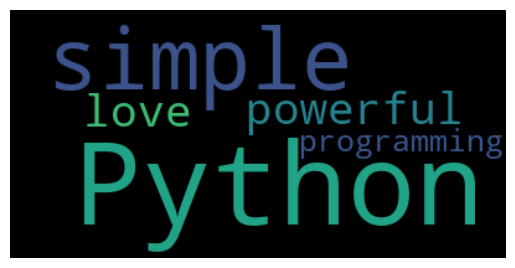

In [53]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text = "Python is simple and powerful. I love Python programming!"
wc = WordCloud().generate(text)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

##### Q4. Choose your own paragraph (~100 words) as training data.
##### 1. Tokenize text using Tokenizer() from keras.preprocessing.text
##### 2. Create input sequences and build a simple LSTM or Dense model
##### 3. Train the model and generate 2–3 new lines of text starƟng from any seed word you provide.

In [64]:
!pip install keras tensorflow

In [66]:
from tensorflow.keras.preprocessing.text import Tokenizer 
from tensorflow.keras.utils import pad_sequences 
text = "Machine learning is fun and exciting to learn"
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
sequences = []
words = text.split()
for i in range(1, len(words)):
    seq = words[:i+1]
    tokenized_seq = tokenizer.texts_to_sequences([' '.join(seq)])[0]
    sequences.append(tokenized_seq)
padded = pad_sequences(sequences)
print(padded)

[[0 0 0 0 0 0 1 2]
 [0 0 0 0 0 1 2 3]
 [0 0 0 0 1 2 3 4]
 [0 0 0 1 2 3 4 5]
 [0 0 1 2 3 4 5 6]
 [0 1 2 3 4 5 6 7]
 [1 2 3 4 5 6 7 8]]


In [68]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense
model = Sequential()
model.add(Embedding(input_dim=50, output_dim=10, input_length=padded.shape[1]))
model.add(LSTM(50))
model.add(Dense(50, activation='relu'))
model.add(Dense(len(tokenizer.word_index)+1, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [88]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import numpy as np

text = """
Machine learning is a fascinating field. It allows computers to learn from data without being explicitly programmed. Deep learning is a subset of machine learning that uses neural networks. These models can recognize patterns in images, speech, and text. With enough data and computational power, AI systems can solve complex problems. Artificial intelligence is now used in healthcare, finance, transportation, and more. Natural language processing enables chatbots and translators to understand human language. As AI continues to evolve, it brings both opportunities and challenges.
"""
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
sequences = []

for line in text.split('.'):
    tokens = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(tokens)):
        sequences.append(tokens[:i+1])

padded = pad_sequences(sequences, padding='pre')

In [90]:
X = padded[:,:-1]
y = padded[:,-1]

model = Sequential()
model.add(Embedding(input_dim=len(tokenizer.word_index)+1, output_dim=10, input_length=X.shape[1]))
model.add(LSTM(50))
model.add(Dense(len(tokenizer.word_index)+1, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
model.fit(X, y, epochs=200, verbose=0)

In [102]:
def generate_text(seed, n_words):
    for _ in range(n_words):
        token = tokenizer.texts_to_sequences([seed])[0]
        token = pad_sequences([token], maxlen=X.shape[1], padding='pre')
        pred_index = np.argmax(model.predict(token, verbose=0), axis=-1)[0]
        for word, idx in tokenizer.word_index.items():
            if idx == pred_index:
                seed += " " + word
                break
    return seed

print(generate_text("Artificial", 5))

Artificial learning is a subset field
